In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)


In [12]:
data = [
    ["Nutraceuticals", "Zincovit Tablet", 75.58],
    ["Nutraceuticals", "Walyte Powder Lemon", 3.20],
    ["Nutraceuticals", "VSL3 Capsule", 318.67],
    ["Nutraceuticals", "Vitaplus Capsule", 197.96],
    ["Nutraceuticals", "Vital Z Powder", 74.40],
    ["Nutraceuticals", "Vit E 400 Capsule", 182.54],
    
    ["OTC", "Zaroor Time Max Condoms", 14.00],
    ["OTC", "Zaroor Condoms", 6.62],
    ["OTC", "Hydrogen Peroxide Solution", 83.59],
    ["OTC", "Ujala Eye Drops", 22.05],
    ["OTC", "Stud 1000 Spray", 67.48],
    ["OTC", "Mask", 2.05],
    
    ["Surgical", "Udayan Adhesive Tape", 58.00],
    ["Surgical", "Infusion Set", 230.09],
    ["Surgical", "Cotton Roll Bandage", 19.90],
    ["Surgical", "Suture Needle", 23.75],
    ["Surgical", "Surgical Spirit", 57.37],
    ["Surgical", "Crepe Bandage", 70.97],
]

df = pd.DataFrame(data, columns=["Category", "Product_Name", "Price"])
df.head()


,Category,Product_Name,Price
0,Nutraceuticals,Zincovit Tablet,75.58
1,Nutraceuticals,Walyte Powder Lemon,3.20
2,Nutraceuticals,VSL3 Capsule,318.67
3,Nutraceuticals,Vitaplus Capsule,197.96
4,Nutraceuticals,Vital Z Powder,74.40


In [13]:
df.shape


(18, 3)

In [14]:
df.dtypes


Category         object
Product_Name     object
Price           float64
dtype: object

In [15]:
df.describe()


,Price
count,18.000000
mean,83.790000
std,89.708145
min,2.050000
25%,20.437500
50%,62.740000
75%,81.587500
max,318.670000


In [16]:
df.isnull().sum()


Category        0
Product_Name    0
Price           0
dtype: int64

In [17]:
df["Category"].unique()


array(['Nutraceuticals', 'OTC', 'Surgical'], dtype=object)

In [20]:
df["Category"].value_counts()


Category
Nutraceuticals    6
OTC               6
Surgical          6
Name: count, dtype: int64

In [21]:
df.groupby("Category")["Price"].mean()


Category
Nutraceuticals    142.058333
OTC                32.631667
Surgical           76.680000
Name: Price, dtype: float64

In [22]:
df.groupby("Category")["Price"].median()


Category
Nutraceuticals    129.060
OTC                18.025
Surgical           57.685
Name: Price, dtype: float64

In [23]:
df.groupby("Category")["Price"].std()


Category
Nutraceuticals    113.343812
OTC                34.299020
Surgical           77.864760
Name: Price, dtype: float64

In [24]:
df.loc[df["Price"].idxmax()]


Category        Nutraceuticals
Product_Name      VSL3 Capsule
Price                   318.67
Name: 2, dtype: object

In [25]:
df.loc[df["Price"].idxmin()]


Category         OTC
Product_Name    Mask
Price           2.05
Name: 11, dtype: object

In [26]:
def price_segment(x):
    if x < 50:
        return "Low"
    elif x < 150:
        return "Medium"
    else:
        return "High"

df["Price_Category"] = df["Price"].apply(price_segment)
df.head()


,Category,Product_Name,Price,Price_Category
0,Nutraceuticals,Zincovit Tablet,75.58,Medium
1,Nutraceuticals,Walyte Powder Lemon,3.20,Low
2,Nutraceuticals,VSL3 Capsule,318.67,High
3,Nutraceuticals,Vitaplus Capsule,197.96,High
4,Nutraceuticals,Vital Z Powder,74.40,Medium


In [27]:
df["Price_Category"].value_counts()


Price_Category
Medium    7
Low       7
High      4
Name: count, dtype: int64

In [28]:
pd.crosstab(df["Category"], df["Price_Category"])


Price_Category,High,Low,Medium
Category,,,
Nutraceuticals,3,1,2
OTC,0,4,2
Surgical,1,2,3


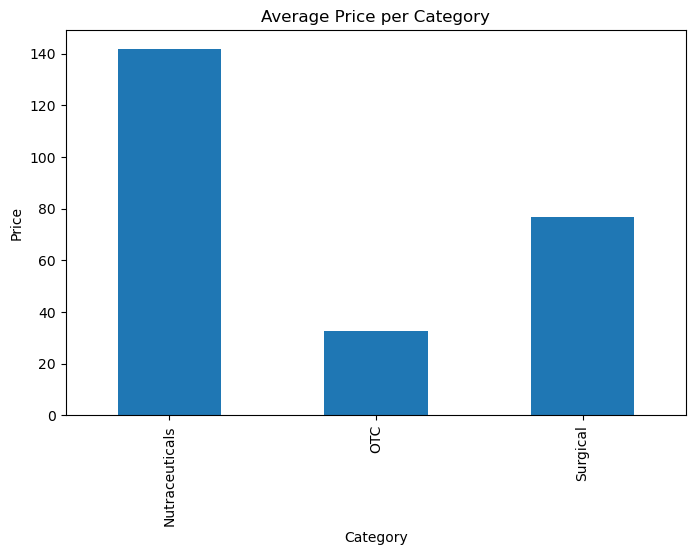

In [29]:
df.groupby("Category")["Price"].mean().plot(kind="bar")
plt.title("Average Price per Category")
plt.ylabel("Price")
plt.show()


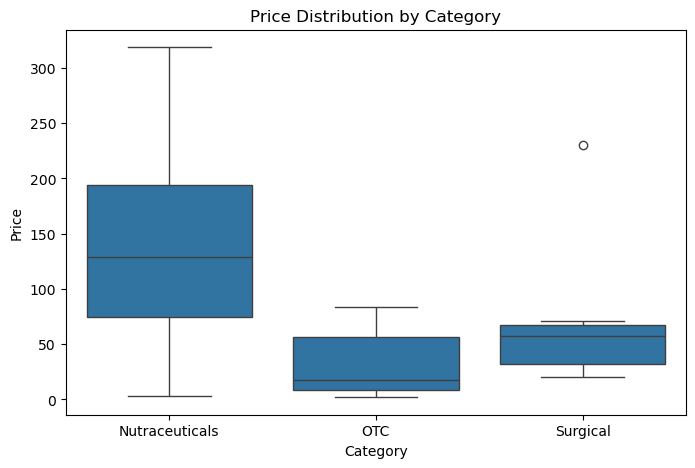

In [30]:
sns.boxplot(x="Category", y="Price", data=df)
plt.title("Price Distribution by Category")
plt.show()


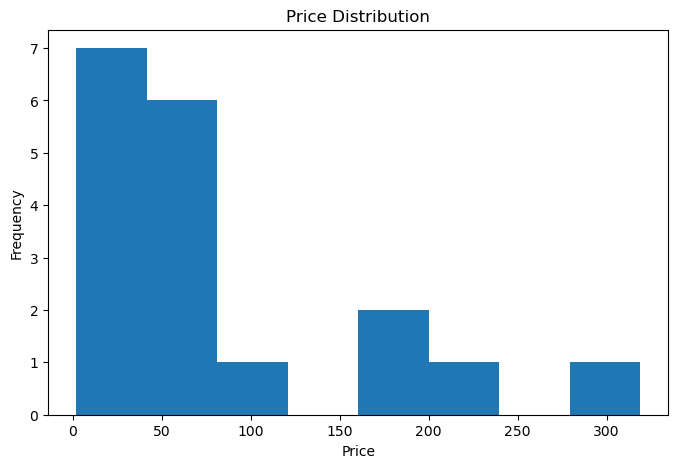

In [31]:
plt.hist(df["Price"], bins=8)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


In [34]:
df_encoded = pd.get_dummies(df, columns=["Category"], drop_first=True)
df_numeric = df_encoded.select_dtypes(include=[np.number])
df_numeric.corr()


,Price
Price,1.0


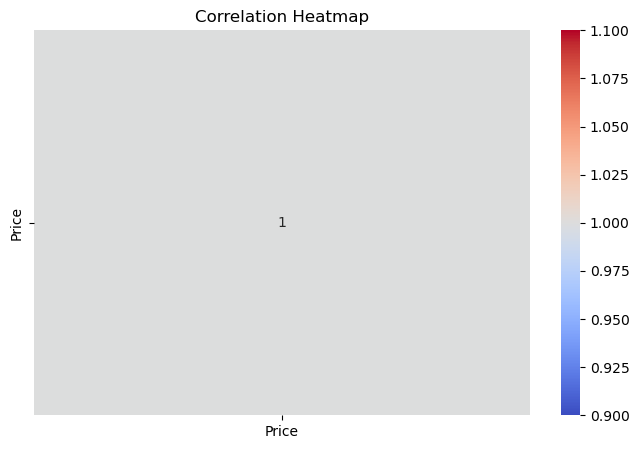

In [35]:
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


### 